# Практика 21. Метод Монте-Карло: обчислення площі та оцінка збіжності

**Варіант 1: Київ**

Мета: оцінити площу чверті одиничного кола методом Монте-Карло, порівняти результат із `π/4` і перевірити порядок похибки `1/√N`.

In [4]:
import numpy as np


def estimate_area(sample_size, seed):
    np.random.seed(seed)
    x = np.random.uniform(0, 1, sample_size)
    y = np.random.uniform(0, 1, sample_size)
    inside = x ** 2 + y ** 2 <= 1
    return inside.mean()

variant = 1
city = 'Київ'
exact_area = np.pi / 4
estimate_1000 = estimate_area(1000, seed=variant)
print(f'Варіант {variant}: {city}')
print(f'Точне значення: π/4 = {exact_area:.6f}')
print(f'Оцінка Monte Carlo при N=1000: {estimate_1000:.6f}')

Варіант 1: Київ
Точне значення: π/4 = 0.785398
Оцінка Monte Carlo при N=1000: 0.770000


## Завдання 1. Оцінка площі методом Монте-Карло

**Варіант 1: Київ, площа чверті одиничного кола.** Генеруємо рівномірні точки в квадраті `[0, 1] × [0, 1]`. Точка належить фігурі, якщо `x² + y² ≤ 1`. Оцінка площі дорівнює частці влучань, помноженій на площу квадрата `1`.

In [3]:
n = 1000
estimate_1000 = estimate_area(n, seed=variant)
absolute_error = abs(estimate_1000 - exact_area)
relative_error_percent = absolute_error / exact_area * 100

print(f'Оцінка площі при N={n}: {estimate_1000:.6f}')
print(f'Точна площа π/4: {exact_area:.6f}')
print(f'Абсолютна похибка: {absolute_error:.6f}')
print(f'Відносна похибка: {relative_error_percent:.3f}%')

Оцінка площі при N=1000: 0.770000
Точна площа π/4: 0.785398
Абсолютна похибка: 0.015398
Відносна похибка: 1.961%


## Завдання 2. Порівняння з точним значенням

Для чверті одиничного кола точна площа дорівнює `π/4 ≈ 0.785398`. Абсолютна похибка — це `|оцінка - π/4|`; також обчислюємо її у відсотках від точного значення.

In [6]:
import pandas as pd

sample_sizes = [100, 1000, 10000, 100000]
rows = []
for sample_size in sample_sizes:
    estimate = estimate_area(sample_size, seed=variant)
    rows.append({
        'N': sample_size,
        'оцінка': estimate,
        'абсолютна_похибка': abs(estimate - exact_area),
    })
results = pd.DataFrame(rows)
print(results.to_string(index=False, float_format=lambda value: f'{value:.8f}'))
print('Збільшення N у 100 разів не гарантує рівно 10-кратного падіння конкретної похибки, але теоретичний масштаб змінюється саме у √100 = 10 разів.')

     N     оцінка  абсолютна_похибка
   100 0.77000000         0.01539816
  1000 0.77000000         0.01539816
 10000 0.78370000         0.00169816
100000 0.78673000         0.00133184
Збільшення N у 100 разів не гарантує рівно 10-кратного падіння конкретної похибки, але теоретичний масштаб змінюється саме у √100 = 10 разів.


## Завдання 3. Збіжність за кількістю випробувань

Повторюємо симуляцію для `N = 100, 1000, 10000, 100000`, щоразу встановлюючи `seed=1` перед генерацією. Для кожного `N` обчислюємо оцінку та абсолютну похибку.

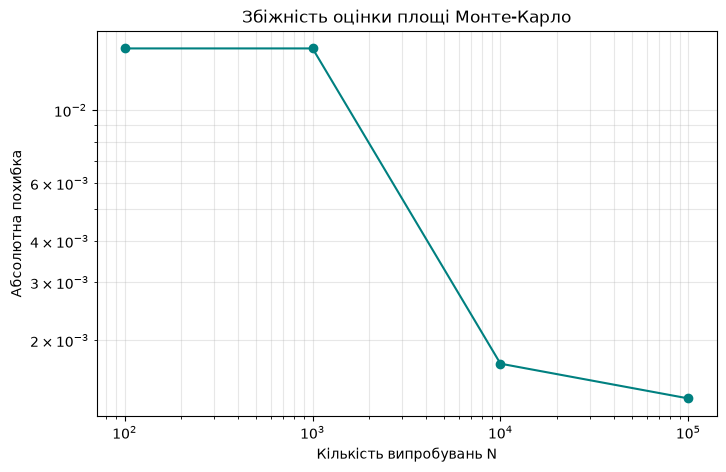

Похибка N=100 / похибка N=10000 = 9.068
Тенденція має порядок 1/√N, але окремі значення можуть коливатися через випадковість.


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results['N'], results['абсолютна_похибка'], marker='o', color='teal')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Кількість випробувань N')
ax.set_ylabel('Абсолютна похибка')
ax.set_title('Збіжність оцінки площі Монте-Карло')
ax.grid(True, which='both', alpha=0.3)
plt.show()

error_100 = results.loc[results['N'] == 100, 'абсолютна_похибка'].iloc[0]
error_10000 = results.loc[results['N'] == 10000, 'абсолютна_похибка'].iloc[0]
print(f'Похибка N=100 / похибка N=10000 = {error_100 / error_10000:.3f}')
print('Тенденція має порядок 1/√N, але окремі значення можуть коливатися через випадковість.')

## Завдання 4. Графік похибки залежно від N

Будуємо графік абсолютної похибки проти `N` у логарифмічній шкалі. Через випадковість похибка не зобов'язана спадати строго на кожному кроці, але її типовий масштаб має зменшуватися приблизно як `1/√N`.

## Завдання 5. Закон великих чисел і ЦГТ

Закон великих чисел гарантує, що вибіркове середнє індикаторів потрапляння збігається з математичним сподіванням при зростанні `N`. ЦГТ пояснює розподіл і стандартну похибку оцінки для великих `N`; саме тому типовий масштаб похибки має порядок `1/√N`.

## Контрольні питання

**1. Чому Monte Carlo — це вибіркове середнє?** Для площі кожна випадкова точка дає індикатор `I`, який дорівнює 1 усередині чверті кола й 0 поза нею. Середнє `I` оцінює ймовірність потрапляння, тобто частку площі.

**2. Чому вчетверо більше випробувань дає лише вдвічі меншу похибку?** Стандартна похибка середнього має вигляд `σ/√N`. Тому збільшення `N` у 4 рази збільшує знаменник лише у 2 рази.

**3. Чому частку множимо на площу квадрата?** Вибірка рівномірна на квадраті площі 1, тому тут множник дорівнює 1. Загалом частка точок усередині фігури є відношенням площ, тому для відновлення площі фігури її треба помножити на площу прямокутника-охоплення.

**4. Як працює `axis` для очікувань?** У задачах із кидками `min(axis=1)` або `max(axis=1)` обчислює один результат для кожного рядка-випробування. Без `axis` агрегується вся матриця в одне число.

## Підсумок

- Площу чверті одиничного кола оцінено методом Монте-Карло.
- Оцінку порівняно з точним значенням `π/4`.
- Перевірено зміну абсолютної похибки для чотирьох значень `N`.
- Побудовано графік похибки в логарифмічній шкалі й пояснено порядок `1/√N` через закон великих чисел і ЦГТ.